# plot the eta car light curve]

[##load data](#load-data)

[convert to AB mag](#convert-to-AB-magnitude)

[estimate temperature](#estimate-temperature)

[estimate radius](#estimate-radius)

[compare with other transients](#compare-with-other-transients)

[period analysis](#period-analysis)



In [22]:
from LC_utility import *

## load data

In [23]:
### Read in Models
lcpath = './data/'
LCm2_i = pd.read_csv(lcpath +'M2_iEtaCarLC.csv')
LCm2_g = pd.read_csv(lcpath +'M2_gEtaCarLC.csv')
LCm2_r = pd.read_csv(lcpath +'M2_rEtaCarLC.csv')
LCm2_z = pd.read_csv(lcpath +'M2_zEtaCarLC.csv')

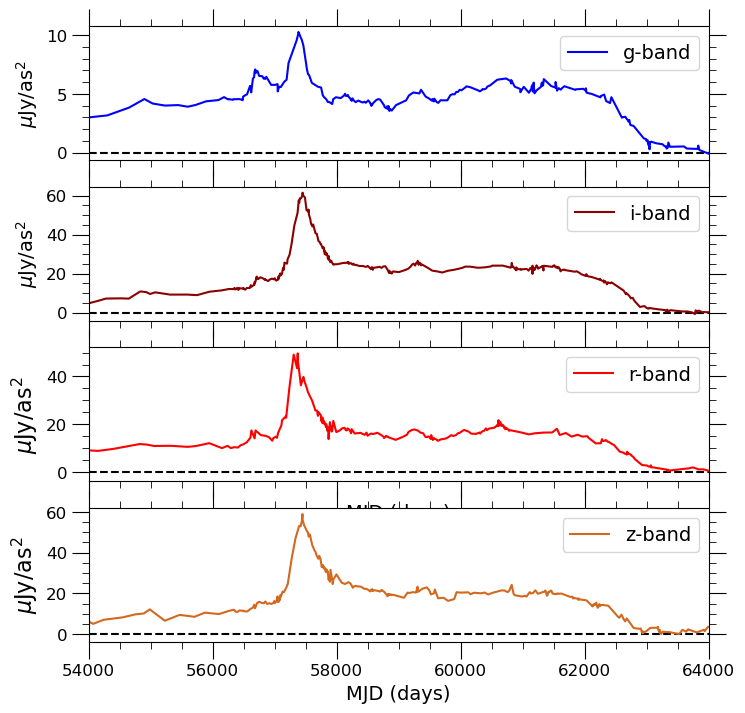

In [24]:
fig, axs = plt.subplots(4,1,dpi = 100, figsize = [8,8], sharex=True)
axs = axs.flatten() 

axs[0].minorticks_on()
axs[0].tick_params(axis='x', labelsize=12)
axs[0].tick_params(axis='y', labelsize=12)
axs[0].tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
axs[0].tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
# axs[0].gca().set_xlabel('mjd', fontsize = 14)
axs[0].set_ylabel(r'$\mu$Jy/as$^2$', fontsize = 14)
axs[0].ticklabel_format(axis='both', style='plain')

axs[0].errorbar(LCm2_g['mjd'], LCm2_g['mJyas2'], fmt='-', ecolor='black', color='blue', label='g-band')
axs[0].axhline(y=0, linestyle='--', color='black')
axs[0].set_xlim(54000, 64000)
axs[0].legend(fontsize = 14)


axs[1].minorticks_on()
axs[1].tick_params(axis='x', labelsize=12)
axs[1].tick_params(axis='y', labelsize=12)
axs[1].tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
axs[1].tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
axs[1].set_ylabel(r'$\mu$Jy/as$^2$', fontsize = 14)
axs[1].ticklabel_format(axis='both', style='plain')

axs[1].errorbar(LCm2_i['mjd'], LCm2_i['mJyas2'], fmt='-', ecolor='black', color='darkred', label='i-band')
axs[1].axhline(y=0, linestyle='--', color='black')
axs[1].set_xlim(54000, 64000)
axs[1].legend(fontsize = 14)


axs[2].minorticks_on()
axs[2].tick_params(axis='x', labelsize=12)
axs[2].tick_params(axis='y', labelsize=12)
axs[2].tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
axs[2].tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
axs[2].set_xlabel('MJD (days)', fontsize = 14)
axs[2].set_ylabel(r'$\mu$Jy/as$^2$', fontsize = 16)
axs[2].ticklabel_format(axis='both', style='plain')

axs[2].errorbar(LCm2_r['mjd'], LCm2_r['mJyas2'], fmt='-', ecolor='black', color='red', label='r-band')
axs[2].axhline(y=0, linestyle='--', color='black')
axs[2].set_xlim(54000, 64000)
axs[2].legend(fontsize = 14)


axs[3].minorticks_on()
axs[3].tick_params(axis='x', labelsize=12)
axs[3].tick_params(axis='y', labelsize=12)
axs[3].tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
axs[3].tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
axs[3].set_xlabel('MJD (days)', fontsize = 14)
axs[3].set_ylabel(r'$\mu$Jy/as$^2$', fontsize = 16)
axs[3].ticklabel_format(axis='both', style='plain')

axs[3].errorbar(LCm2_z['mjd'], LCm2_z['mJyas2'], fmt='-', ecolor='black', color='chocolate', label='z-band')
axs[3].axhline(y=0, linestyle='--', color='black')
axs[3].set_xlim(54000, 64000)
axs[3].legend(fontsize = 14)

## convert to AB magnitude

In [25]:
working_inds_i = np.where(LCm2_i['mJyas2']>0.)[0]
working_inds_g = np.where(LCm2_g['mJyas2']>0.)[0]
working_inds_r = np.where(LCm2_r['mJyas2']>0.)[0]
working_inds_z = np.where(LCm2_z['mJyas2']>0.)[0]

mag_i, mag_err_i = convert_Jy2mag(LCm2_i.loc[working_inds_i,'mJyas2'].values, LCm2_i.loc[working_inds_i,'mJyas2_err'].values)
mag_g, mag_err_g = convert_Jy2mag(LCm2_g.loc[working_inds_g,'mJyas2'].values, LCm2_g.loc[working_inds_g,'mJyas2_err'].values)
mag_r, mag_err_r = convert_Jy2mag(LCm2_r.loc[working_inds_r,'mJyas2'].values, LCm2_r.loc[working_inds_r,'mJyas2_err'].values)
mag_z, mag_err_z = convert_Jy2mag(LCm2_z.loc[working_inds_z,'mJyas2'].values, LCm2_z.loc[working_inds_z,'mJyas2_err'].values)

LCm2_i.loc[working_inds_i,'AB_mag'] = np.array(mag_i)
LCm2_i.loc[working_inds_i,'AB_mag_err'] = np.array(mag_err_i)
LCm2_g.loc[working_inds_g,'AB_mag'] = np.array(mag_g)
LCm2_g.loc[working_inds_g,'AB_mag_err'] = np.array(mag_err_g)
LCm2_r.loc[working_inds_r,'AB_mag'] = np.array(mag_r)
LCm2_r.loc[working_inds_r,'AB_mag_err'] = np.array(mag_err_r)
LCm2_z.loc[working_inds_z,'AB_mag'] = np.array(mag_z)
LCm2_z.loc[working_inds_z,'AB_mag_err'] = np.array(mag_err_z)

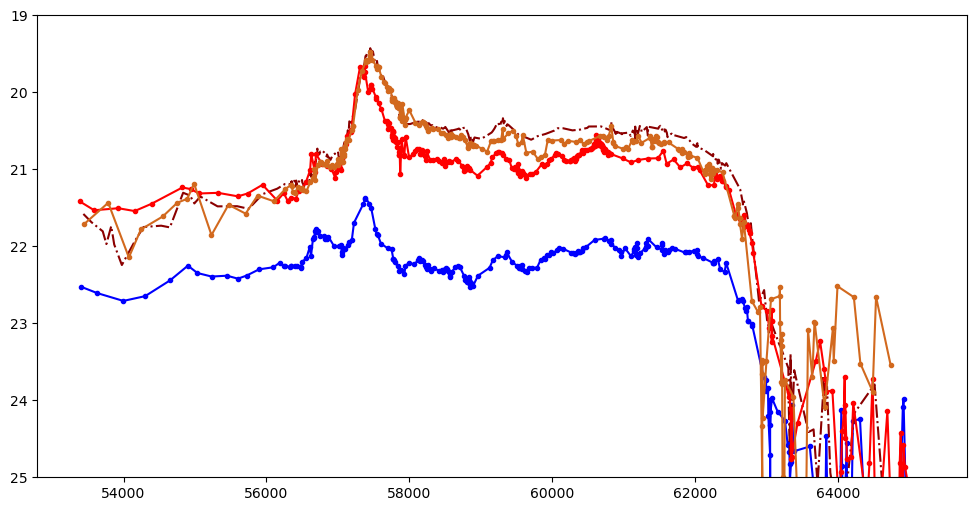

In [26]:
plt.subplots(dpi = 100, figsize = [12,6])
plt.errorbar(LCm2_g.loc[working_inds_g,'mjd'], LCm2_g.loc[working_inds_g,'AB_mag'], fmt='.-', ecolor='black', color='blue')
plt.errorbar(LCm2_i.loc[working_inds_i,'mjd'], LCm2_i.loc[working_inds_i,'AB_mag'], fmt='-.', ecolor='black', color='darkred')
plt.errorbar(LCm2_r.loc[working_inds_r,'mjd'], LCm2_r.loc[working_inds_r,'AB_mag'], fmt='.-', ecolor='black', color='red')
plt.errorbar(LCm2_z.loc[working_inds_z,'mjd'], LCm2_z.loc[working_inds_z,'AB_mag'], fmt='.-', ecolor='black', color='chocolate')


plt.ylim(19,25)
plt.gca().invert_yaxis()

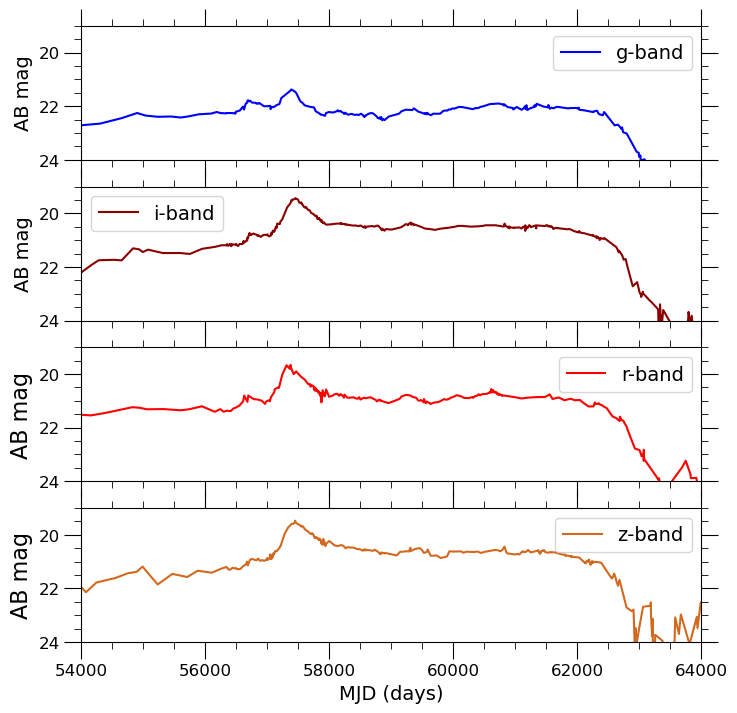

In [27]:
fig, axs = plt.subplots(4,1,dpi = 100, figsize = [8,8], sharex=True)
axs = axs.flatten() 

axs[0].minorticks_on()
axs[0].tick_params(axis='x', labelsize=12)
axs[0].tick_params(axis='y', labelsize=12)
axs[0].tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
axs[0].tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
# axs[0].gca().set_xlabel('mjd', fontsize = 14)
axs[0].set_ylabel('AB mag', fontsize = 14)
axs[0].ticklabel_format(axis='both', style='plain')

axs[0].errorbar(LCm2_g.loc[working_inds_g,'mjd'], LCm2_g.loc[working_inds_g,'AB_mag'], fmt='-', ecolor='black', color='blue', label='g-band')
axs[0].set_xlim(54000, 64000)
axs[0].set_ylim(19,24)
axs[0].invert_yaxis()
axs[0].legend(fontsize = 14)


axs[1].minorticks_on()
axs[1].tick_params(axis='x', labelsize=12)
axs[1].tick_params(axis='y', labelsize=12)
axs[1].tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
axs[1].tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
axs[1].set_ylabel('AB mag', fontsize = 14)
axs[1].ticklabel_format(axis='both', style='plain')

axs[1].errorbar(LCm2_i.loc[working_inds_i,'mjd'], LCm2_i.loc[working_inds_i,'AB_mag'], fmt='-', ecolor='black', color='darkred', label='i-band')
axs[1].set_xlim(54000, 64000)
axs[1].set_ylim(19,24)
axs[1].invert_yaxis()
axs[1].legend(fontsize = 14)


axs[2].minorticks_on()
axs[2].tick_params(axis='x', labelsize=12)
axs[2].tick_params(axis='y', labelsize=12)
axs[2].tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
axs[2].tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
axs[2].set_ylabel('AB mag', fontsize = 16)
axs[2].ticklabel_format(axis='both', style='plain')

axs[2].errorbar(LCm2_r.loc[working_inds_r,'mjd'], LCm2_r.loc[working_inds_r,'AB_mag'], fmt='-', ecolor='black', color='red', label='r-band')
axs[2].set_xlim(54000, 64000)
axs[2].set_ylim(19,24)
axs[2].invert_yaxis()
axs[2].legend(fontsize = 14)


axs[3].minorticks_on()
axs[3].tick_params(axis='x', labelsize=12)
axs[3].tick_params(axis='y', labelsize=12)
axs[3].tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
axs[3].tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
axs[3].set_xlabel('MJD (days)', fontsize = 14)
axs[3].set_ylabel('AB mag', fontsize = 16)
axs[3].ticklabel_format(axis='both', style='plain')

axs[3].errorbar(LCm2_z.loc[working_inds_z,'mjd'], LCm2_z.loc[working_inds_z,'AB_mag'], fmt='-', ecolor='black', color='chocolate', label='z-band')
axs[3].set_xlim(54000, 64000)
axs[3].set_ylim(19,24)
axs[3].invert_yaxis()
axs[3].legend(fontsize = 14)

In [28]:
t_ran = np.arange(54000, 63500)

i_new = splev(t_ran, splrep(LCm2_i.loc[working_inds_i,'mjd'], LCm2_i.loc[working_inds_i,'AB_mag'], k=1))
# i_new_err = splev(t_ran, splrep(LCm2_i.loc[working_inds_i,'mjd'], LCm2_i.loc[working_inds_i,'AB_mag_err'], k=1))
g_new = splev(t_ran, splrep(LCm2_g.loc[working_inds_g,'mjd'], LCm2_g.loc[working_inds_g,'AB_mag'], k=1))
# g_new_err = splev(t_ran, splrep(LCm2_g.loc[working_inds_g,'mjd'], LCm2_g.loc[working_inds_g,'AB_mag_err'], k=1))

r_new = splev(t_ran, splrep(LCm2_r.loc[working_inds_r,'mjd'], LCm2_r.loc[working_inds_r,'AB_mag'], k=1))
z_new = splev(t_ran, splrep(LCm2_z.loc[working_inds_z,'mjd'], LCm2_z.loc[working_inds_z,'AB_mag'], k=1))

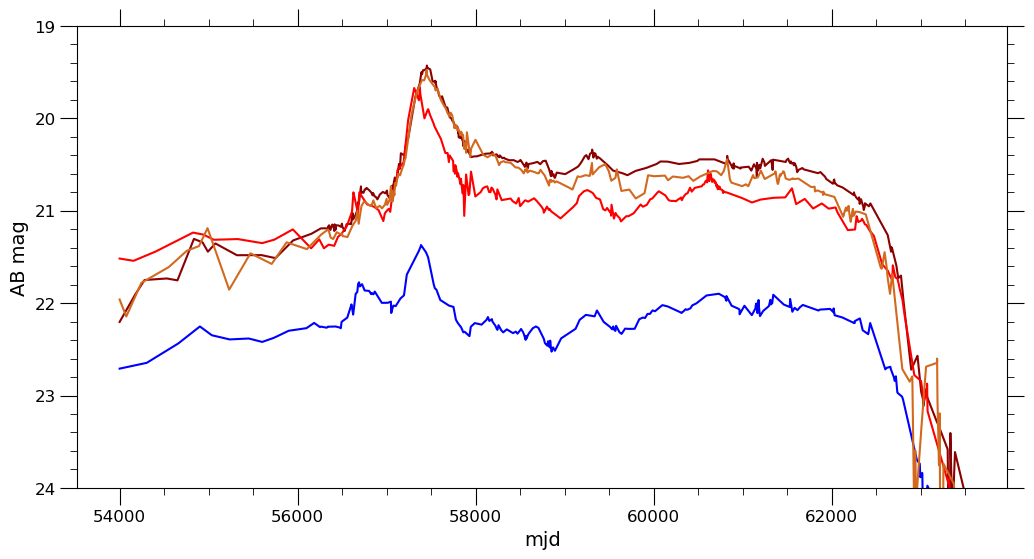

In [29]:
plt.subplots(dpi = 100, figsize = [12,6])
plt.minorticks_on()
plt.tick_params(axis='x', labelsize=12)
plt.tick_params(axis='y', labelsize=12)
plt.tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
plt.tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
plt.gca().set_xlabel('mjd', fontsize = 14)
plt.gca().set_ylabel('AB mag', fontsize = 14)
plt.ticklabel_format(axis='both', style='plain')


plt.errorbar(t_ran, g_new, ecolor='black', color='blue')
plt.errorbar(t_ran, i_new, ecolor='black', color='darkred')
plt.errorbar(t_ran, r_new, ecolor='black', color='red')
plt.errorbar(t_ran, z_new, ecolor='black', color='chocolate')

plt.ylim(19,24)
plt.gca().invert_yaxis()

# plt.axvline(54850, color='k', ls='--')
# plt.axvline(56740, color='k', ls='--')
# plt.axvline(57430, color='k', ls='--')
# plt.axvline(59300, color='k', ls='--')

## color plot

(0.0, 3.5)

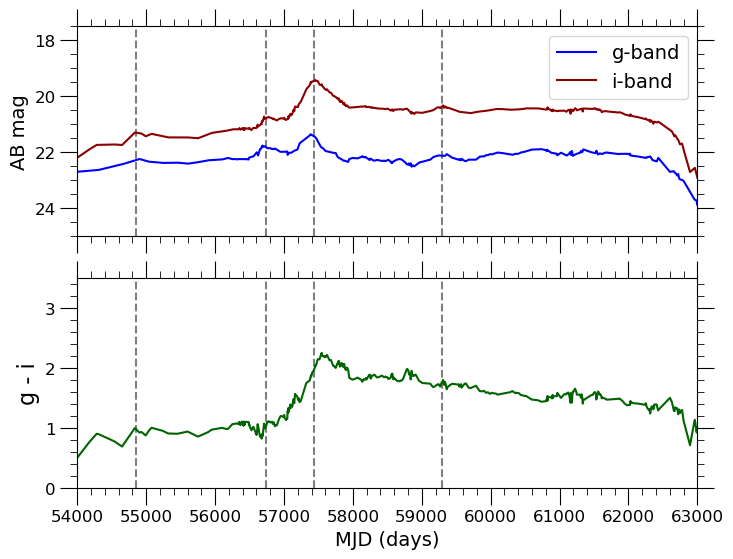

In [59]:
# g - i

fig, axs = plt.subplots(2,1,dpi = 100, figsize = [8,6], sharex=True)
axs = axs.flatten() 
axs[0].minorticks_on()
axs[0].tick_params(axis='x', labelsize=12)
axs[0].tick_params(axis='y', labelsize=12)
axs[0].tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
axs[0].tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
# axs[0].gca().set_xlabel('mjd', fontsize = 14)
axs[0].set_ylabel('AB mag', fontsize = 14)
axs[0].ticklabel_format(axis='both', style='plain')

axs[0].errorbar(t_ran, g_new, ecolor='black', color='blue',label='g-band')
axs[0].errorbar(t_ran, i_new, ecolor='black', color='darkred',label='i-band')

axs[0].axvline(54850, color='k', ls='--', alpha=0.5)
axs[0].axvline(56740, color='k', ls='--', alpha=0.5)
axs[0].axvline(57430, color='k', ls='--', alpha=0.5)
axs[0].axvline(59300, color='k', ls='--', alpha=0.5)
# axs[0].set_xlim(54000, 63000)
axs[0].set_ylim(17.5, 25)
axs[0].invert_yaxis()
axs[0].legend(fontsize = 14)

axs[1].minorticks_on()
axs[1].tick_params(axis='x', labelsize=12)
axs[1].tick_params(axis='y', labelsize=12)
axs[1].tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
axs[1].tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
axs[1].set_xlabel('MJD (days)', fontsize = 14)
axs[1].set_ylabel('g - i', fontsize = 16)
axs[1].ticklabel_format(axis='both', style='plain')

axs[1].errorbar(t_ran, g_new-i_new, ecolor='black', color='darkgreen')
axs[1].axvline(54850, color='k', ls='--', alpha=0.5)
axs[1].axvline(56740, color='k', ls='--', alpha=0.5)
axs[1].axvline(57430, color='k', ls='--', alpha=0.5)
axs[1].axvline(59300, color='k', ls='--', alpha=0.5)
axs[1].set_xlim(54000, 63000)
axs[1].set_ylim(0.0, 3.5)

# fig.savefig('../figures/display/EtaCar_ColorPlot.png', bbox_inches = 'tight', dpi = 100)


## estimate temperature

In [60]:
# data from A. Alonso et al.: Empirical calibration of Teff versus colours and [Fe/H].
t_effs = np.array([3500,3750,4000,4250,4500,4750,5000,5250,5500,5750,6000,6250,6500,6750,7000,7250,7500,7750,8000 ])

V_Is = np.array([2.800,2.210,1.865,1.625,1.435,1.275,1.135,1.015,0.910,0.815,0.725,0.645,0.575,0.505,0.440,0.380,0.325,0.275,0.225])


Theta = 5040 / t_effs



In [61]:

np.polyfit(V_Is, Theta, deg=3)

array([-0.0192951 ,  0.0197577 ,  0.41923694,  0.53356974])

In [79]:
def vi_to_Teff(vi):
    """
    Convert (V-I) color to Teff [K] = 5040 / Theta.


    Theta = a0 + a1(V-I) + a2 (V-I)**2 + a3 (V-I)**3
    
    Reference: A. Alonso et al.: Empirical calibration of Teff versus colours and [Fe/H].
    """
    vi = np.asarray(vi)

    # value from np.polyfit
    a3, a2, a1, a0 = -0.0192951 ,  0.0197577 ,  0.41923694,  0.53356974
    
    Theta = a0 + a1 * vi + a2 * vi ** 2 + a3 * vi ** 3
    
    return 5040 / Theta

def gi_to_VI(gi):
    """
    Convert g-i to V-I, from
    https://www.sdss3.org/dr8/algorithms/sdssUBVRITransform.php#Jordi2006
    """
    VI = (0.675)*(gi)  + (0.364)
    return VI


Text(0, 0.5, 'Teff')

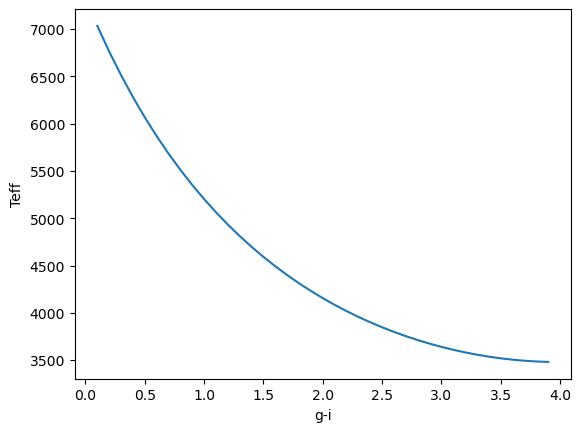

In [80]:
# the gi-Temperature relation

gi_s = np.arange(0.1, 4, .1)
vi_s = gi_to_VI(gi_s)

Teff_s = vi_to_Teff(vi_s)

plt.plot(gi_s, Teff_s)

plt.xlabel('g-i')
plt.ylabel('Teff')

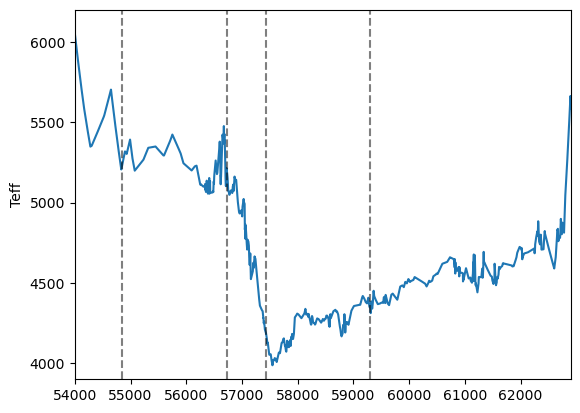

In [190]:
color_gi = g_new - i_new

T = vi_to_Teff( gi2VI(color_gi) )

plt.plot(t_ran, T)
#plt.ylim([3900, 6000])
#plt.gca().invert_yaxis()

plt.ylabel('Teff')

plt.xlim([54000, 62900])
plt.ylim([3900, 6200])


plt.axvline(54850, color='k', ls='--', alpha=0.5)
plt.axvline(56740, color='k', ls='--', alpha=0.5)
plt.axvline(57430, color='k', ls='--', alpha=0.5)
plt.axvline(59300, color='k', ls='--', alpha=0.5)


## estimate radius

In [81]:
# Constants
R_sun = 6.957e10       # Solar radius in cm

T_sun = 5772           # Solar effective temperature in K
M_bol_sun = 4.74       # Solar bolometric magnitude

# Example bolometric correction function for i-band
# For simplicity, we use a linear approximation here; replace with real table for accuracy
def BC_i(T_eff):
    # Simple approximation: hotter stars have smaller (more negative) BC
    return 0.1 - 0.0001 * (T_eff - 5772)

def radius_from_Mi_Teff(M_i, T_eff):
    """
    Compute stellar radius in solar radii from i-band magnitude and effective temperature.
    
    Parameters
    ----------
    M_i : float
        Absolute magnitude in i-band
    T_eff : float
        Effective temperature in Kelvin
    
    Returns
    -------
    R : float
        Stellar radius in solar radii
    """
    BC = BC_i(T_eff)
    log_R_Rsun = (M_bol_sun - M_i - BC)/5 - 2*np.log10(T_eff/T_sun)
    R = 10**log_R_Rsun
    
    return R


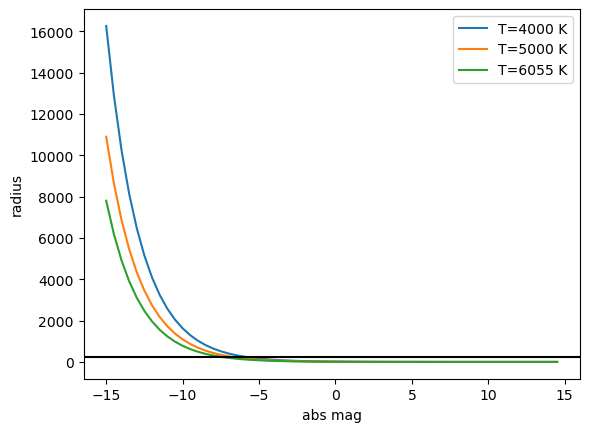

In [196]:
# radius, mag, temperature ralation

mags = np.arange(-15, 15, .5)

for ti in [4000, 5000, 6055]:
    r = radius_from_Mi_Teff(mags, ti,)

    plt.plot(mags, r, label=f'T={ti} K')

plt.axhline(y=240, c='k')
plt.xlabel('abs mag')
plt.ylabel('radius')
plt.legend()

In [183]:
# assume initial has a 240R_sun radius
# from, Theodore R. Gull JD13 – Eta Carinae in the Context of the Most Massive Stars

abs_mag = mags[ np.argmin( np.abs(r - 240) )]

# initial magnitude
abs_mag - i_new[0]

np.float64(-29.703695376242077)

In [218]:
22-35

-13

In [226]:
color_gi = g_new - i_new

T = vi_to_Teff( gi2VI(color_gi) )

R_ec = radius_from_Mi_Teff(i_new-29.7, T)


Text(0, 0.5, 'R')

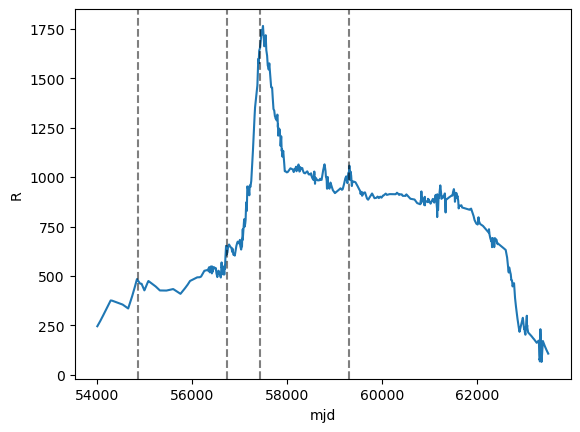

In [227]:
plt.plot(t_ran, R_ec)

plt.axvline(54850, color='k', ls='--', alpha=0.5)
plt.axvline(56740, color='k', ls='--', alpha=0.5)
plt.axvline(57430, color='k', ls='--', alpha=0.5)
plt.axvline(59300, color='k', ls='--', alpha=0.5)

plt.xlabel('mjd')
plt.ylabel('R')


In [216]:
1200 * R_sun / (2*365*24*3600) /100/1000



132.3630136986301

## HR diagram

Text(4343.683793950043, -9.32514251528631, '1850 peak')

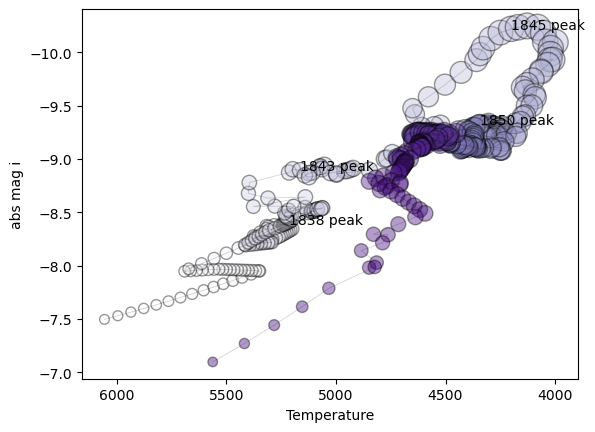

In [194]:

idx = t_ran < 62900

step = 20

color_gi = g_new[idx][::step] - i_new[idx][::step]
mag_i = i_new[idx][::step] 
abs_mag_i = mag_i-29.7


t = t_ran[idx][::step]

T = vi_to_Teff( gi_to_VI(color_gi) )

R_ec = radius_from_Mi_Teff(abs_mag_i, T)


plt.plot(T, abs_mag_i, '-', alpha=.2, c='k', lw=.5)

plt.scatter( T, abs_mag_i , alpha=0.4, s=R_ec/5, edgecolors='black',
            c=t, cmap=plt.cm.Purples, )


plt.gca().invert_yaxis()

plt.gca().invert_xaxis()

plt.xlabel('Temperature');
plt.ylabel('abs mag i')


mjd_peak1 = 54850
idx_peak1 = np.argmin(np.abs(t_ran[::step] - mjd_peak1))

plt.text(T[idx_peak1], abs_mag_i[idx_peak1], '1838 peak')


mjd_peak1 = 56740
idx_peak1 = np.argmin(np.abs(t_ran[::step] - mjd_peak1))
plt.text(T[idx_peak1], abs_mag_i[idx_peak1], '1843 peak')


mjd_peak1 = 57430
idx_peak1 = np.argmin(np.abs(t_ran[::step] - mjd_peak1))
plt.text(T[idx_peak1], abs_mag_i[idx_peak1], '1845 peak')

mjd_peak1 = 59300
idx_peak1 = np.argmin(np.abs(t_ran[::step] - mjd_peak1))

plt.text(T[idx_peak1], abs_mag_i[idx_peak1], '1850 peak')



## compare with other transients

### load LRN and ILRT model

In [31]:
modelname = 'data/other_transients/gpmodels_for_publication/lrn_gmodel.pickle'
with open(modelname,'rb') as f:
    lrn_gmodel = pickle.load(f)

modelname = 'data/other_transients/gpmodels_for_publication/lrn_rmodel.pickle'
with open(modelname,'rb') as f:
    lrn_rmodel = pickle.load(f)


modelname = 'data/other_transients/gpmodels_for_publication/ilrt_gmodel.pickle'
with open(modelname,'rb') as f:
    ilrt_gmodel = pickle.load(f)

modelname = 'data/other_transients/gpmodels_for_publication/ilrt_rmodel.pickle'
with open(modelname,'rb') as f:
    ilrt_rmodel = pickle.load(f)


/Users/home/miniconda3/envs/sklearn-env/lib/python3.13/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator GaussianProcessRegressor from version 0.23.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Text(0.5, 1.0, 'Luminous Red Novae model')

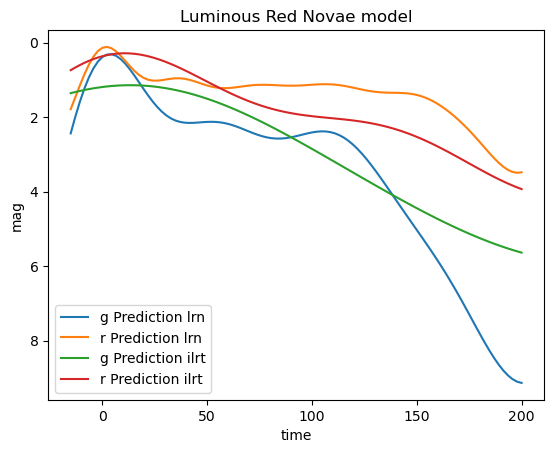

In [32]:
x = np.atleast_2d(np.linspace(-15,200,100)).T

y_pred_g_lrn, sigma_g_lrn = lrn_gmodel.predict(x, return_std=True)

y_pred_r_lrn, sigma_r_lrn = lrn_rmodel.predict(x, return_std=True)


y_pred_g_ilrt, sigma_g_ilrt = ilrt_gmodel.predict(x, return_std=True)

y_pred_r_ilrt, sigma_r_ilrt = ilrt_rmodel.predict(x, return_std=True)


plt.plot(x, y_pred_g_lrn, c=plt.cm.tab10(0), label='g Prediction lrn')
plt.plot(x, y_pred_r_lrn, c=plt.cm.tab10(1), label='r Prediction lrn')

plt.plot(x, y_pred_g_ilrt, c=plt.cm.tab10(2), label='g Prediction ilrt')
plt.plot(x, y_pred_r_ilrt, c=plt.cm.tab10(3), label='r Prediction ilrt')


plt.gca().invert_yaxis()

plt.legend()

plt.xlabel('time')
plt.ylabel('mag')

plt.title('Luminous Red Novae model')

### UGC2773 unfiltered

In [38]:
lc_ugc = pd.read_csv('./data/other_transients/UGC2773_unfiltered.csv', sep=r'\s+')

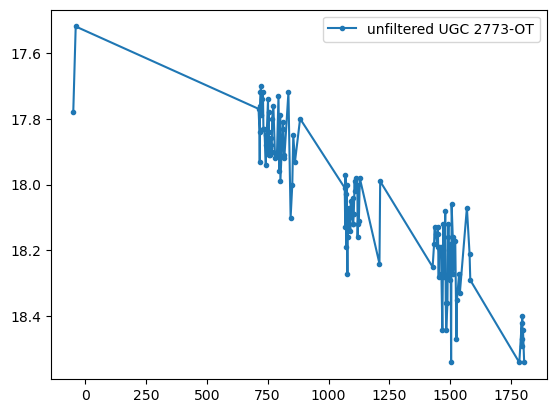

In [40]:
t_ugc = lc_ugc['MJD'].values - 55100
mag_ugc = lc_ugc['mag'].values

plt.plot(t_ugc, mag_ugc, '.-', label='unfiltered UGC 2773-OT')

plt.gca().invert_yaxis()
plt.legend()

(-1000.0, 2000.0)

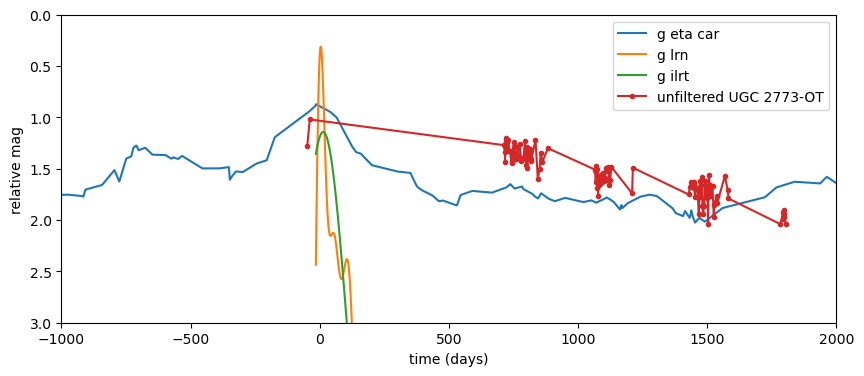

In [303]:
plt.figure(figsize=(10, 4))

plt.plot(t_ran-57400, g_new-20.5, label='g eta car')

plt.plot(x, y_pred_g_lrn, label='g lrn')

plt.plot(x, y_pred_g_ilrt, label='g ilrt')

plt.plot(t_ugc, mag_ugc-16.5, '.-', label='unfiltered UGC 2773-OT')

plt.ylim([0, 3])
plt.gca().invert_yaxis()

plt.xlabel('time (days)')
plt.ylabel('relative mag')
plt.legend()

plt.xlim([-1000, 2000])



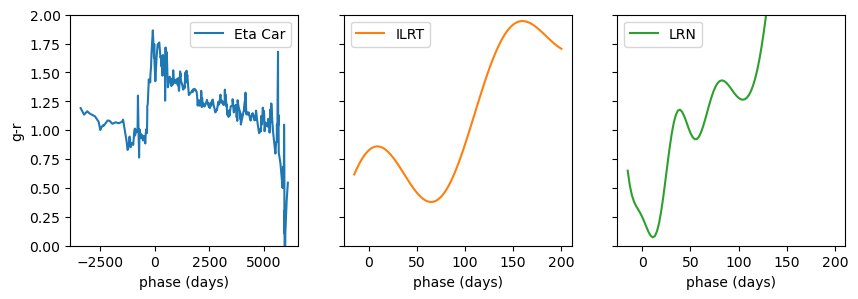

In [302]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3), sharey=True)

ax = axs[0]
ax.plot(t_ran-57400, g_new-r_new, label='Eta Car', c=plt.matplotlib.cm.tab10(0))
ax.set_ylim([0, 2])
ax.set_ylabel('g-r')
ax.set_xlabel('phase (days)')
ax.legend()

ax = axs[1]
ax.plot(x, y_pred_g_ilrt-y_pred_r_ilrt, label='ILRT', c=plt.matplotlib.cm.tab10(1))
ax.set_xlabel('phase (days)')
ax.legend()


ax = axs[2]
ax.plot(x, y_pred_g_lrn-y_pred_r_lrn, label='LRN', c=plt.matplotlib.cm.tab10(2))
ax.set_xlabel('phase (days)')
ax.legend()

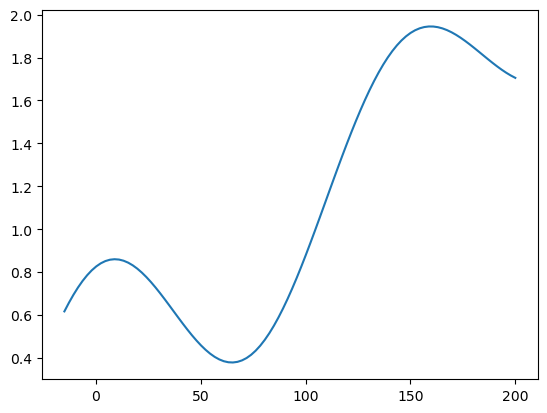

In [239]:
plt.plot(x, , label='g ilrt')


## period analysis

In [198]:

t_ran = np.arange(54000, 63500)

g_flux_new = splev(t_ran, splrep(LCm2_g.loc[working_inds_g,'mjd'], LCm2_g.loc[working_inds_g,'mJyas2'], k=1))




Text(0, 0.5, 'flux')

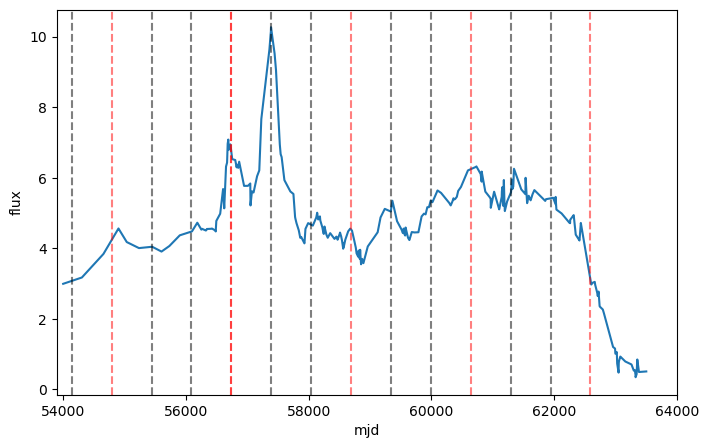

In [253]:
plt.figure(figsize=(8, 5))

plt.plot(t_ran, g_flux_new)

peak1 = 54850
peak2 = 56740
peak3 = 57430
peak4 = 59300

#axs.axvline(peak1, color='k', ls='--', alpha=0.5)
#axs.axvline(peak2, color='k', ls='--', alpha=0.5)
#axs.axvline(peak3, color='k', ls='--', alpha=0.5)
#axs.axvline(peak4, color='k', ls='--', alpha=0.5)

ax = plt.gca()
#-------
for i in range(10):
    c = 'r' if i%3==0 else 'k'
    ax.axvline(peak2 + 650*i, color=c, ls='--', alpha=0.5)
    ax.axvline(peak2 - 650*i, color=c, ls='--', alpha=0.5)


plt.xlim([53900, 64000])

plt.xlabel('mjd')

plt.ylabel('flux')

In [241]:

T_ = t_ran[t_ran<62000]
g_ = g_flux_new[t_ran<62000]

Duration = T_.max() - T_.min()

Nsample = len(T_)

Sample_rate = Nsample / Duration

In [242]:
Fourier = np.fft.fft( g_)

Freq = np.fft.fftfreq(Nsample, 1/Sample_rate)

In [243]:
Fourier_mag = np.abs(Fourier)


/var/folders/yb/hm0wbr8128v_fbvy474l5s6m0000gn/T/ipykernel_9884/2864997150.py:1: RuntimeWarning: divide by zero encountered in divide
  periods = 1/Freq/365


Text(0, 0.5, 'ampitude')

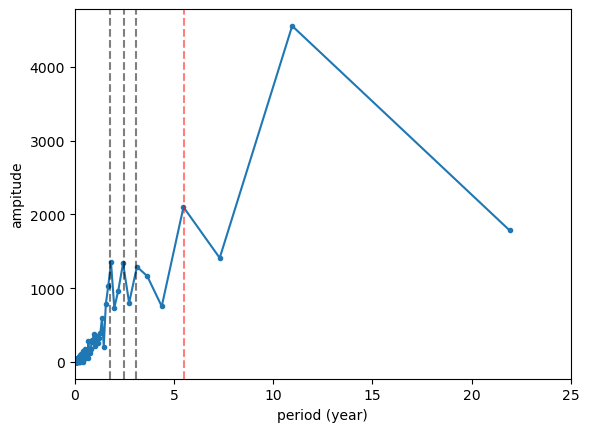

In [251]:

periods = 1/Freq/365
plt.plot(periods, Fourier_mag, '.-')

plt.xlim(0, 25)

plt.axvline(1.8, c='k', ls='--', alpha=0.5)
plt.axvline(2.5, c='k', ls='--', alpha=0.5)
plt.axvline(3.1, c='k', ls='--', alpha=0.5)

plt.axvline(5.5, c='r', ls='--', alpha=0.5)
#plt.axvline(11, )

plt.xlabel('period (year)')

plt.ylabel('ampitude')



In [275]:
Fourier_new = Fourier.copy()
#Fourier_new[Fourier_mag<1000] = 0


#Fourier_new[Fourier_mag<1200] = 0
Fourier_new[(np.abs(periods)<1.5) | (np.abs(periods)>25)] = 0


iFourier = np.fft.ifft(Fourier_new)

Fourier_new_mag = np.abs(Fourier_new)


/var/folders/yb/hm0wbr8128v_fbvy474l5s6m0000gn/T/ipykernel_9884/131401637.py:1: RuntimeWarning: divide by zero encountered in divide
  plt.plot(1/Freq/365, Fourier_mag, '.-')
/var/folders/yb/hm0wbr8128v_fbvy474l5s6m0000gn/T/ipykernel_9884/131401637.py:3: RuntimeWarning: divide by zero encountered in divide
  plt.plot(1/Freq/365, Fourier_new_mag, '.-')


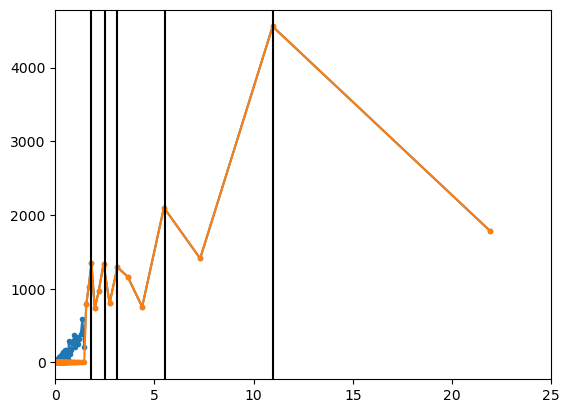

In [276]:
plt.plot(1/Freq/365, Fourier_mag, '.-')

plt.plot(1/Freq/365, Fourier_new_mag, '.-')

plt.xlim(0, 25)

plt.axvline(1.8, c='k')
plt.axvline(2.5, c='k')
plt.axvline(3.1, c='k')

plt.axvline(5.54, c='k')
plt.axvline(11, c='k')



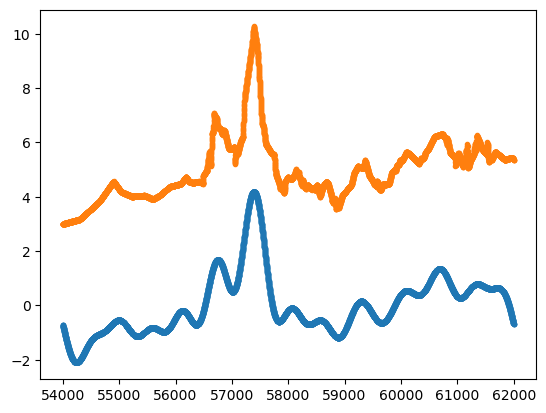

In [277]:
plt.plot(T_, iFourier, '.')
plt.plot(T_, g_, '.')